In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [7]:

print(df.info())
print(df.isnull().sum())
print(df['Attrition'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

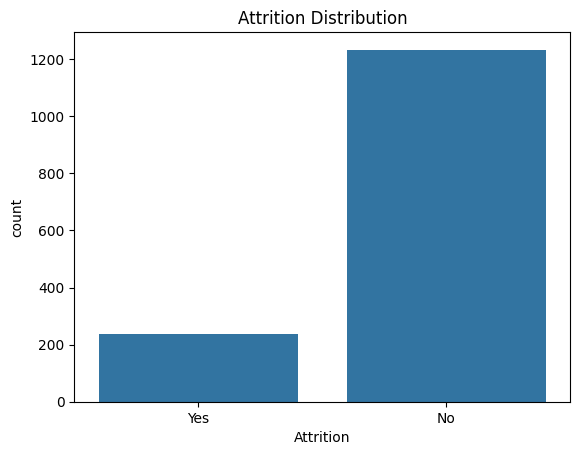

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

In [9]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [11]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'Attrition':
        df[col] = le.fit_transform(df[col])


df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


print( df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:", y_train.value_counts().to_dict())


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train.value_counts().to_dict())


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}

X_train: (1972, 30)
y_train: (1972,)
X_test: (294, 30)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [14]:
model = Sequential()


model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))


model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,697 (84.75 KB)

 Trainable params: 21,185 (82.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [17]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6288 - loss: 0.7644 - val_accuracy: 0.6190 - val_loss: 0.6131
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7216 - loss: 0.5690 - val_accuracy: 0.6905 - val_loss: 0.5864
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7510 - loss: 0.5101 - val_accuracy: 0.7381 - val_loss: 0.5456
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7835 - loss: 0.4761 - val_accuracy: 0.7755 - val_loss: 0.5467
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7992 - loss: 0.4457 - val_accuracy: 0.7925 - val_loss: 0.5432
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8048 - loss: 0.4299 - val_accuracy: 0.7891 - val_loss: 0.5662
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8291 - loss: 0.4028 - val_accuracy: 0.7959 - val_loss: 0.5511
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8251 - loss: 0.3937 - val_accuracy: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8435 - loss: 0.4777 

 Final Test Accuracy: 0.8435
 Final Test Loss: 0.4777
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


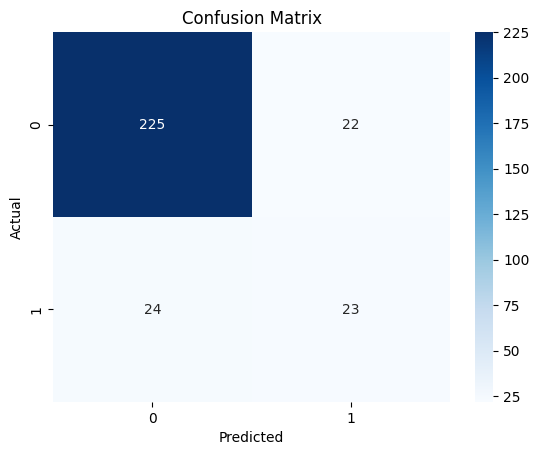


 Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       247
           1       0.51      0.49      0.50        47

    accuracy                           0.84       294
   macro avg       0.71      0.70      0.70       294
weighted avg       0.84      0.84      0.84       294

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8435 - loss: 0.4777

 Final Test Accuracy: 0.8435
 Final Test Loss: 0.4777
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


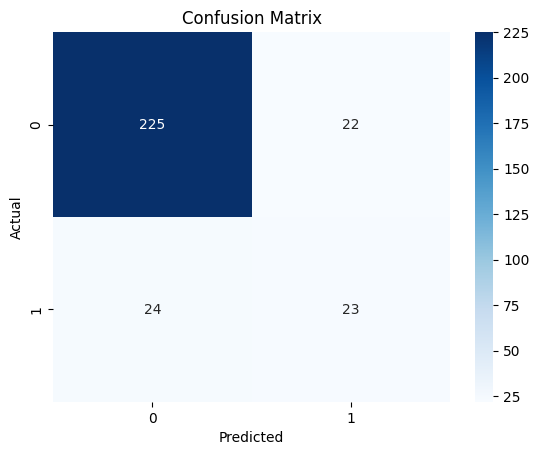


 Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       247
           1       0.51      0.49      0.50        47

    accuracy                           0.84       294
   macro avg       0.71      0.70      0.70       294
weighted avg       0.84      0.84      0.84       294



In [19]:

loss, acc = model.evaluate(X_test, y_test)
print(f"\n Final Test Accuracy: {acc:.4f}")
print(f" Final Test Loss: {loss:.4f}")


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

In [21]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

class_weight = {0: 1, 1: 3}


y_pred = (model.predict(X_test) > 0.4).astype(int)



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [22]:
from sklearn.metrics import classification_report

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred = (model.predict(X_test) > threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Threshold: 0.3
              precision    recall  f1-score   support

        Stay       0.90      0.78      0.84       247
       Leave       0.33      0.55      0.41        47

    accuracy                           0.74       294
   macro avg       0.61      0.67      0.62       294
weighted avg       0.81      0.74      0.77       294

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Threshold: 0.35
              precision    recall  f1-score   support

        Stay       0.91      0.83      0.87       247
       Leave       0.38      0.55      0.45        47

    accuracy                           0.79       294
   macro avg       0.64      0.69      0.66       294
weighted avg       0.82      0.79      0.80       294

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Threshold: 0.4
              precision    recall  f1-score   support

        Stay       0.91      0.85      0.88       247
       Leave       0.41      0.55      0.47        47

    accuracy 

In [23]:
# Model save
model.save('attrition_model.h5')
print("✅ Model saved!")

# Scaler save
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved!")

# Threshold save
with open('threshold.txt', 'w') as f:
    f.write('0.38')
print("✅ Threshold saved (0.38)!")

# Test with final threshold
threshold = 0.38
y_pred = (model.predict(X_test) > threshold).astype(int)
print("\n📊 Final Model Performance:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

✅ Model saved!
✅ Scaler saved!
✅ Threshold saved (0.38)!
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 Final Model Performance:
              precision    recall  f1-score   support

        Stay       0.91      0.84      0.87       247
       Leave       0.40      0.55      0.46        47

    accuracy                           0.80       294
   macro avg       0.65      0.70      0.67       294
weighted avg       0.83      0.80      0.81       294

